# 05.3 · Impulse noise and nonlinear filters

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain impulse noise and nonlinear filters using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[02 · Mathematics for Computer Vision](../../02-mathematics-for-computer-vision/README.md), [04 · OpenCV Fundamentals](../../04-opencv-fundamentals/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Filtering replaces a pixel using its neighborhood. Think of a small window sliding across a spreadsheet. The weights in that window form a kernel. Different weights preserve, blur or emphasize different spatial patterns, and boundary handling changes the answer near image edges.

## 2. Intuition

Salt-and-pepper noise creates extreme pixels, so an average spreads the corruption. Median filtering selects the middle neighborhood value and often handles impulses better. Bilateral filtering also weights intensity similarity to preserve some edges. Speckle is multiplicative noise; its magnitude grows with signal intensity. No single filter solves every noise process.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 5
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
Y_{ij}=\sum_{u=-r}^{r}\sum_{v=-r}^{r}K_{uv}X_{i+u,j+v}
$$

X is the input, K the kernel, Y the result, and r the window radius. A 3×3 mean kernel has nine weights of 1/9. A neighborhood containing values 1 through 9 therefore produces 5.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
patch = np.arange(1, 10, dtype=float).reshape(3, 3)
kernel = np.ones((3, 3)) / 9
value = np.sum(patch * kernel)
assert np.isclose(value, 5)
print(value)

5.0


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The reference implementation pads explicitly and loops over pixels. OpenCV uses optimized kernels and vectorized hardware. Match dtype, correlation convention and border mode before comparing results.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def filtering(lesson, seed, amount):
    clean = n.gray(picture(seed))/255
    rng = np.random.default_rng(seed)
    if lesson == 1:
        noisy = clean.copy(); noise = rng.random(clean.shape)
        noisy[noise < .04*amount] = 0; noisy[noise > 1-.04*amount] = 1
        output = median_filter(noisy,size=3)
        comparison = cv2.medianBlur((noisy*255).astype(np.uint8),3)/255
    else:
        noisy = np.clip(clean+rng.normal(0,.08*amount,clean.shape),0,1)
        kernel = n.gaussian_kernel(5,1 if lesson==0 else 1.7)
        output = n.correlate(noisy,kernel)
        comparison = cv2.filter2D(noisy,-1,kernel,borderType=cv2.BORDER_REPLICATE)
    return Result('05 · Noise and local filtering',{'Clean':clean,'Noisy':noisy,'Reference output':output,'OpenCV comparison':comparison}, metrics={'noisy_mse':float(np.mean((clean-noisy)**2)),'filtered_mse':float(np.mean((clean-output)**2)),'library_max_error':float(np.max(np.abs(output-comparison)))})

{
  "noisy_mse": 0.00639952402451605,
  "filtered_mse": 0.0025466821016679867,
  "library_max_error": 4.440892098500626e-16
}



## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import correlate

display(Code(inspect.getsource(correlate), language="python"))

def correlate(image, kernel):
    """Odd-sized correlation with replicated borders; no kernel reversal."""
    image, kernel = np.asarray(image, float), np.asarray(kernel, float)
    if image.ndim != 2 or kernel.ndim != 2 or any(v % 2 != 1 for v in kernel.shape):
        raise ValueError('Use a 2D image and an odd-sized 2D kernel.')
    ry, rx = np.array(kernel.shape) // 2
    padded = np.pad(image, ((ry, ry), (rx, rx)), mode='edge')
    out = np.empty_like(image)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            out[y, x] = np.sum(padded[y:y+kernel.shape[0], x:x+kernel.shape[1]] * kernel)
    return out

## 8. Experiment

Use equal noise seeds to compare mean, Gaussian and median filtering. Report MSE against the clean synthetic image and also inspect whether thin edges disappear.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "noisy_mse": 0.00639952402451605,
    "filtered_mse": 0.0025466821016679867,
    "library_max_error": 4.440892098500626e-16
  },
  "second_seed": {
    "noisy_mse": 0.00635898559935966,
    "filtered_mse": 0.002539839809003982,
    "library_max_error": 4.440892098500626e-16
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

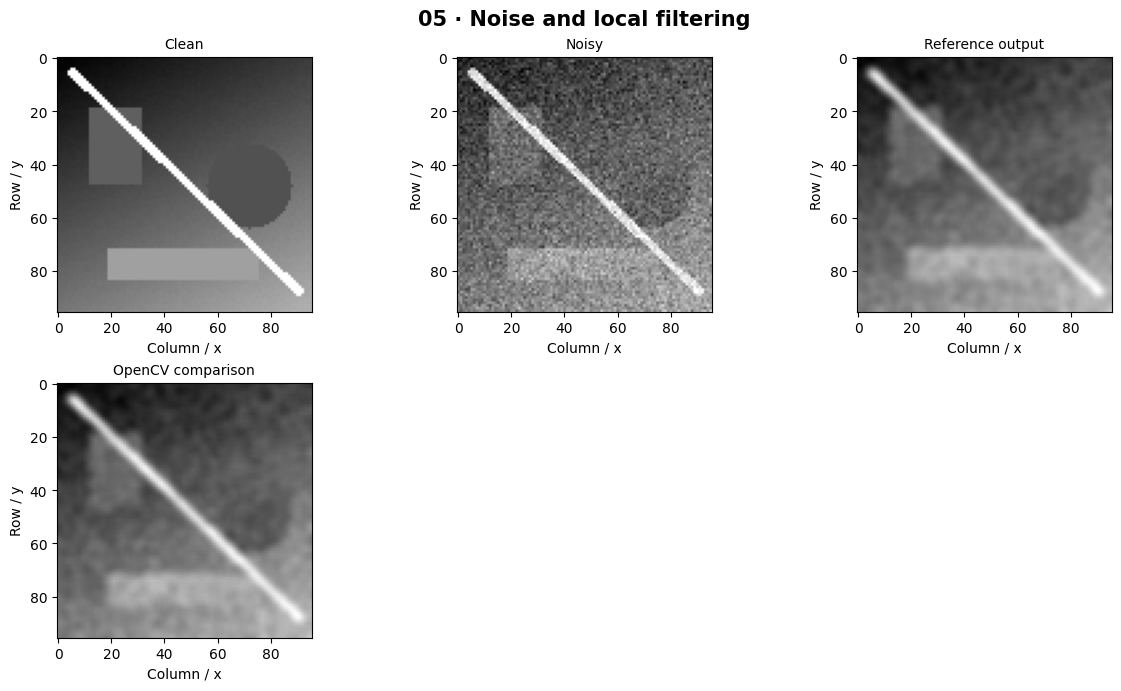

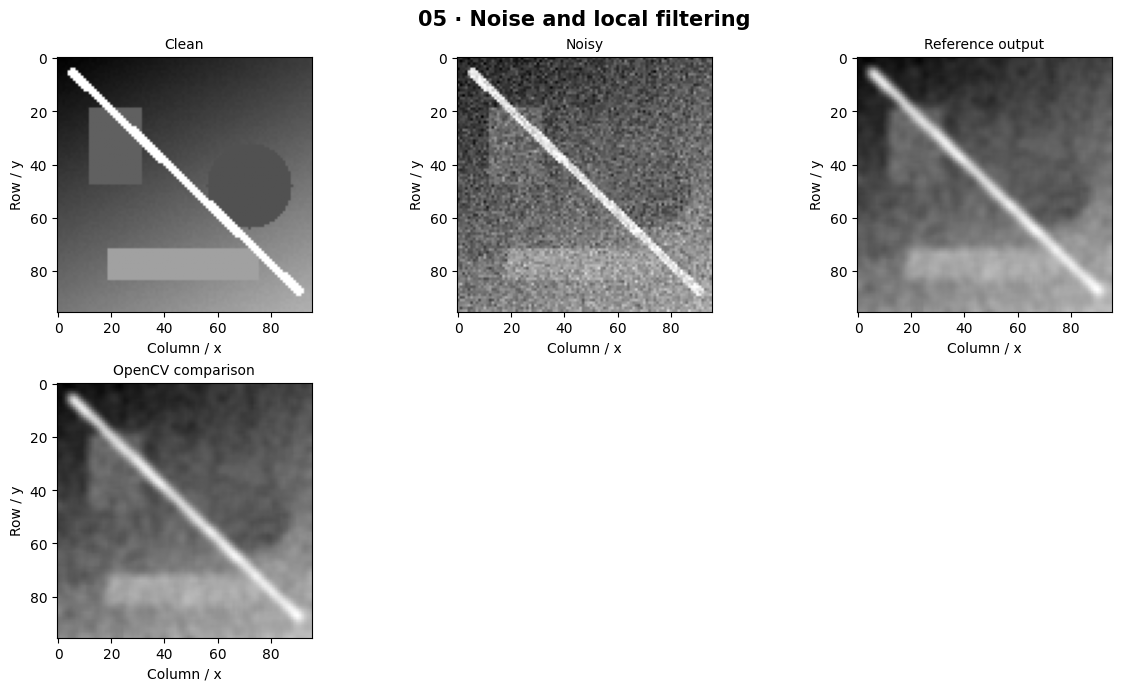

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Image Restoration Lab**. Implement a sliding window and compare denoising methods. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Smoothing may lower noise while removing a real small object. Numerical equality comparisons are invalid when border modes differ.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Use equal noise seeds to compare mean, Gaussian and median filtering. Report MSE against the clean synthetic image and also inspect whether thin edges disappear.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Design an image restoration lab that chooses among three filters from measured noise statistics and reports failure cases.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Salt-and-pepper noise creates extreme pixels, so an average spreads the corruption. Median filtering selects the middle neighborhood value and often handles impulses better. Bilateral filtering also weights intensity similarity to preserve some edges. Speckle is multiplicative noise; its magnitude grows with signal intensity. No single filter solves every noise process.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[06 · Image Enhancement](../../06-image-enhancement/README.md)

[Primary reference](https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)